In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

## Band 5

I opened the Stokes I image for Band 5 in CARTA, made a circle around the source and then used the stats wiget to find the max value:
Max: 9.961923933588e-5 Jy/beam

In [4]:
S_source = 9.962e-5 * 1000
S_source


# This occurs at (765, 482)

0.09962

Using the distance measurement tool the points (506, 510) and (765, 482) are 4.689164 arcsec apart

Also: 
Distance in x: (from 506 to 765 pixels)
Distance in y: 4.681973 (from 510 to 482 pixels)



Distance:

(506, 510) to (506, 482): 0.504000

(765, 510) to (765, 482): 0.504000

(765, 482) to (506, 482): 4.662000

(765, 510) to (506, 510): 4.662000

In [15]:
x_dist = 4.662000
y_dist = 0.504000
hypot_dist = 4.689164

In [19]:
# checking that this adds up:

np.sqrt(x_dist**2 + y_dist**2)

4.689164104613956

The value of $S_0$ = 1.7 mJy applies for Band 6 (1.3 mm) only. This was a value from Table 3 in Carniani, 2015 (https://ui.adsabs.harvard.edu/abs/2015A%26A...584A..78C/abstract). This table also has the value listed for 1.1 mm. 

Based on this source: https://www.eso.org/public/teles-instr/alma/receiver-bands/

Band 5: 1.4–1.8 ()

Band 6: 1.1–1.4 (I call this 1.3 mm)

Band 7: 0.8–1.1 (I call this 0.87 mm)

I will double check this, but it seems that it is fair to use $S_0$ = 2.6 mJy for Band 7 (I can double check this or I will try to find another source for Band 5 and see if they have Band 7 as well)

I will also note that Table 2 in this paper has $S$ vs $dS/d\log(S)$ and $N_{detection}$ values that might be useful to refer back to as a sanity check?

As of now, I cannot find the equivalent parameters for Band 5 and Band 7, so I will stick witht the model for Band 6 that we have in place now, and set up the things (functions?) needed to find the probability

https://academic.oup.com/mnras/article/518/1/1378/6767621



## Primary Beam and Centre Point

In [5]:
pb_path = band5_data_folder_path + "IRS63_BAND5_pb.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

ny, nx = pb_map.shape

In [6]:
flat_index = np.nanargmax(pb_map)   # ignores NaNs, finds max
y_cen, x_cen = np.unravel_index(flat_index, pb_map.shape)

print(rf'The centre position is: (y, x) = ({y_cen}, {x_cen}), and at this position pb = {pb_map[y_cen, x_cen]}')

The centre position is: (y, x) = (506, 510), and at this position pb = 1.0


In [7]:
dr_arcsec = 0.25
dr_deg = arcsec_to_degrees(dr_arcsec)

dr_pix = arcsec_to_pixels(header, dr_arcsec)

In [8]:
r_pix = np.arange(0, nx - x_cen, dr_pix)
r_arcsec = pixels_to_arcsec(header, r_pix)


df = pd.DataFrame({
    "r_pix": r_pix,
    "r_arcsec": r_arcsec,
    "r_deg": arcsec_to_degrees(r_arcsec)
})

In [9]:
x_pos = x_cen + r_pix.astype(int)

pb_val_arr = pb_map[y_cen, x_pos].astype(np.float32).newbyteorder('=')  # native endian
sigma_r_arr = (0.03 / pb_val_arr).astype(np.float32).newbyteorder('=')

df["pb_val"] = pb_val_arr
df["sigma_r"] = sigma_r_arr

df["area_annulus"] = 2 * np.pi * df["r_deg"] * dr_deg

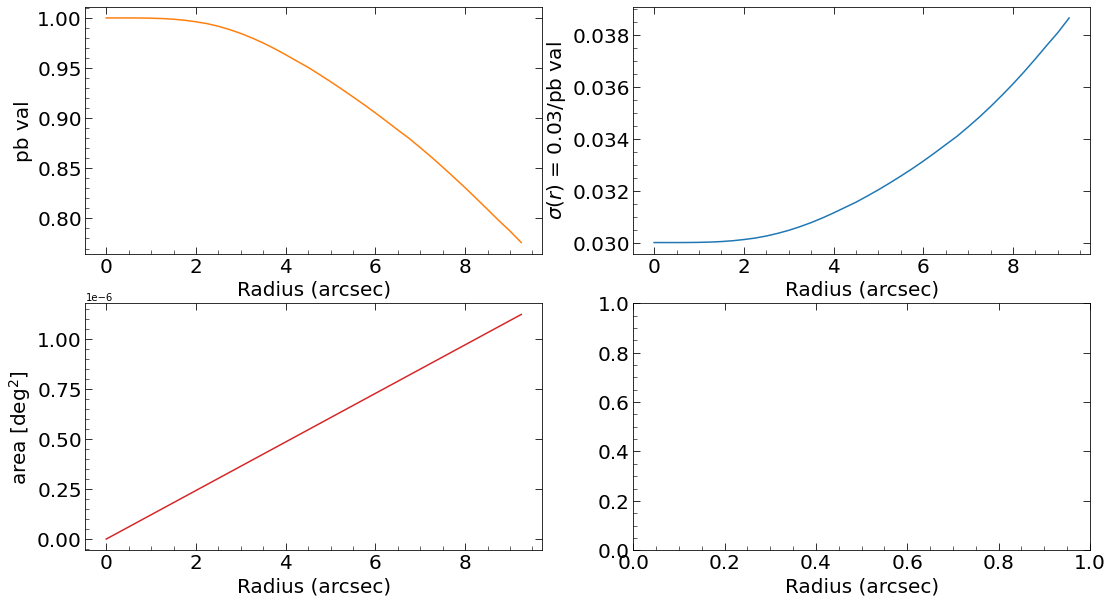

In [10]:
fig, ax = plot_galaxy_contamination_models(df)

In [11]:
# Dictionary to hold each df
df_sn_dict = {}

for sn in [5, 10, 20]:
    # Compute flux threshold per annulus
    S = sn * df["sigma_r"].values
    
    dN_dS = np.array([galaxy_probability(s, 'Band 6') for s in S])

    N_per_area_list = []

    # Loop over each annulus
    for S_min in S:
        # Use your function to integrate dN/dS above threshold
        N_per_area = find_N_from_dN_dS(S_min)
        N_per_area_list.append(N_per_area)

    N = np.array(N_per_area_list)

    # Multiply by annulus area to get expected number per annulus
    N_expected = N * df["area_annulus"].values
   
    prob = 100*(1 - np.exp(-N_expected))
    
    N_cumulative = np.cumsum(N_expected)
    prob_cumulative = 100 * (1 - np.exp(-N_cumulative))

    df_sn = pd.DataFrame({
        "r_arcsec": df["r_arcsec"].values,
        "S_mJy": S,
        "dN_dS": dN_dS,
        "N": N,
        "N_expected": N_expected,
        "prob": prob,
        "prob_cumulative": prob_cumulative
    })

    # Save in dictionary
    df_sn_dict[f"df_{sn}sigma"] = df_sn

# Access like:
df_5sigma = df_sn_dict["df_5sigma"]
df_10sigma = df_sn_dict["df_10sigma"]
df_20sigma = df_sn_dict["df_20sigma"]


In [12]:
dfs = [df_5sigma, df_10sigma, df_20sigma]
sn_array = [5, 10, 20]


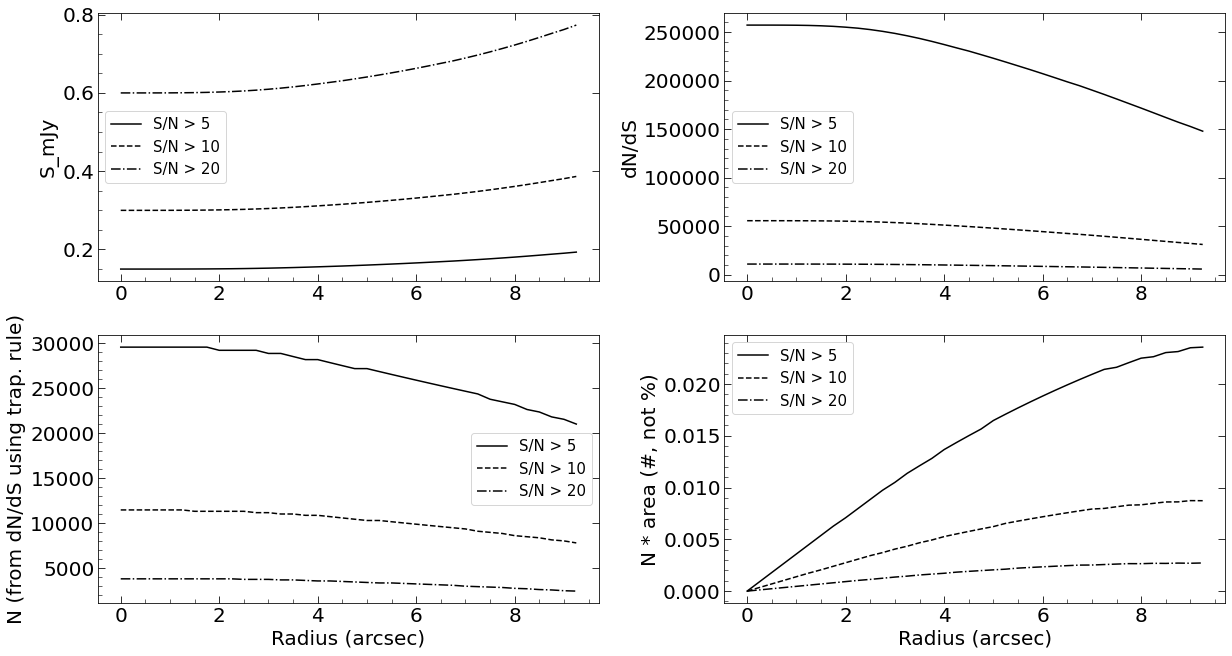

In [13]:
fig, ax = plot_probability_models(dfs, sn_array)

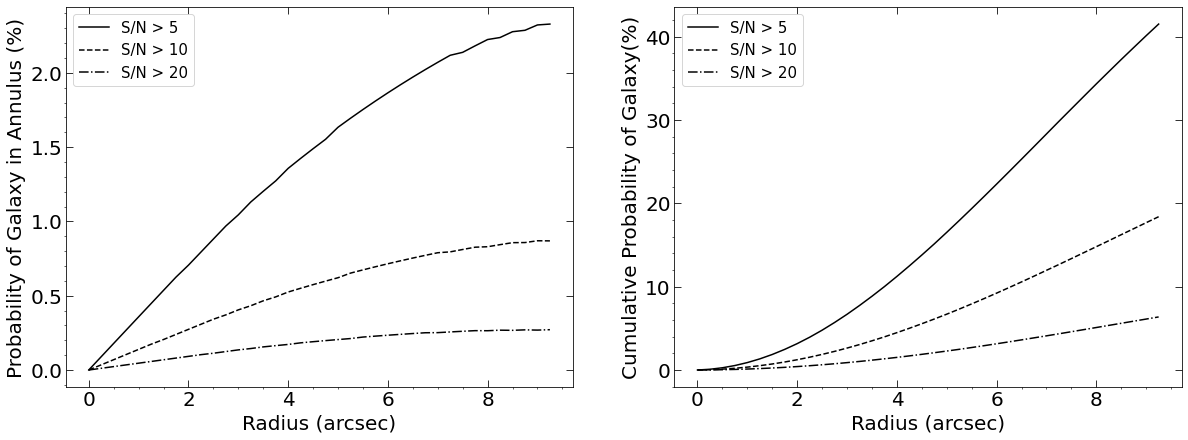

In [27]:
fig, ax = recreate_figs_11_12_sadavoy2019(dfs, sn_array)

## Find probability

In [20]:
x_dist = 4.662000
y_dist = 0.504000
hypot_dist = 4.689164

In [21]:
S_source

0.09962

In [33]:
err = constants.StokesI_err_mJy_band5

S_N_source = S_source / err

S_N_source

6.930086956521739

In [50]:
print(rf"The distance to the source is: {x_dist} arcsec")

closest_r = df["r_arcsec"].iloc[(df["r_arcsec"] - x_dist).abs().argmin()]
closest_idx = (df["r_arcsec"] - x_dist).abs().argmin()

print(rf"The closest r is: {closest_r } arcsec")


print(" ")
print(" ")

for i in range(len(sn_array)):

    print(rf"If the source S/N > {sn_array[i]}:")
    print(rf"     The cumulative prob is: {dfs[i]['prob_cumulative'][closest_idx]:.2f}%")
    print(" ")

The distance to the source is: 4.662 arcsec
The closest r is: 4.75 arcsec
 
 
If the source S/N > 5:
     The cumulative prob is: 15.14%
 
If the source S/N > 10:
     The cumulative prob is: 6.12%
 
If the source S/N > 20:
     The cumulative prob is: 2.08%
 


In [53]:
StokesI_source_band7 = 4.008985706605e-4 * 1000

err_band7 = constants.StokesI_err_mJy_band7

S_N_source_band7 = StokesI_source_band7 / err_band7

S_N_source_band7

11.397258583098793